In [3]:
!pip install kaggle

https://colab.research.google.com/drive/1yWheDQG3gcfQUrufzFKfefvbxxq1rdxG#scrollTo=1e75a614

In [4]:
# 1. Cấu hình thư mục chứa Kaggle API Key
# Lưu ý: Bạn cần tải file 'kaggle.json' lên thư mục làm việc hiện tại của Colab trước khi chạy cell này!
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
# 2. Tải dataset Sentiment140 từ Kaggle bằng API
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:05<00:00, 16.6MB/s]



In [6]:
# 3. Giải nén tập tin dữ liệu đã tải về
!unzip -q sentiment140.zip -d sentiment140_data

# Hiển thị danh sách các file sau khi giải nén
!ls -lh sentiment140_data

total 228M
-rw-r--r-- 1 root root 228M Sep 21  2019 training.1600000.processed.noemoticon.csv


In [7]:
import pandas as pd

# Đọc dữ liệu (Sử dụng encoding='latin-1' vì dữ liệu chứa các ký tự đặc biệt)
# Bộ dữ liệu không có sẵn dòng tiêu đề (header)
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df = pd.read_csv('sentiment140_data/training.1600000.processed.noemoticon.csv', encoding='latin-1', names=columns)

# Hiển thị thông tin tổng quan và 5 dòng đầu tiên
print(f"Tổng số dòng: {len(df):,}")
df.head()

Tổng số dòng: 1,600,000


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [8]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [9]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [10]:
# printing the stopwords in english
print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [11]:
#loading the data from csv file to pandas dataframe
twitter_data = df
twitter_data.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [12]:
twitter_data.shape

(1600000, 6)

In [13]:
#counting the number of missing values in the dataset
twitter_data.isnull().sum()

,0
target,0
ids,0
date,0
flag,0
user,0
text,0


In [14]:
#checking the distribution of target columns
#0- negative , 4-positive
twitter_data['target'].value_counts()

,count
target,
0,800000
4,800000


In [15]:
#convert to 1
twitter_data.replace({'target':{4:1}}, inplace=True)

In [16]:
twitter_data['target'].value_counts()

,count
target,
0,800000
1,800000


In [17]:
port_stem = PorterStemmer()

In [18]:
def stemming(content):
    if not isinstance(content, str):
        return ""
    # Thay thế ký tự không phải chữ cái bằng khoảng trắng
    stemmed_content = re.sub(r'[^a-zA-Z]', ' ', content)
    stemmed_content = stemmed_content.lower()

    # List comprehension kết hợp kiểm tra trong set stop_words
    words = [
        port_stem.stem(word)
        for word in stemmed_content.split()
        if word not in stop_words
    ]
    return ' '.join(words)

In [19]:
# Cài đặt thư viện swifter để xử lý song song
!pip install swifter

import swifter
from nltk.corpus import stopwords

# Khởi tạo danh sách stop words tiếng Anh dưới dạng set để tìm kiếm cực nhanh
stop_words = set(stopwords.words('english'))

# Swifter tự động tối ưu hóa và chạy đa luồng cực nhanh
twitter_data['stemmed_content'] = twitter_data['text'].swifter.apply(stemming)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16589 sha256=1a0d81256e7d80ed08061b9f4899fcb0f651a62ccb3d1acc7a62a6a109dd0b55
  Stored in directory: /root/.cache/pip/wheels/e8/a1/09/564d4c4662764b4113f97a9b2b9a5cf15a5dbf86428c8d3658
Successfully built swifter


Pandas Apply:   0%|          | 0/1600000 [00:00<?, ?it/s]

In [20]:
twitter_data.head()
#

,target,ids,date,flag,user,text,stemmed_content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",switchfoot http twitpic com zl awww bummer sho...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,kenichan dive mani time ball manag save rest g...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",nationwideclass behav mad see


In [21]:
#separating the data and label
X = twitter_data['stemmed_content'].values
Y = twitter_data['target'].values

In [22]:
X

array(['switchfoot http twitpic com zl awww bummer shoulda got david carr third day',
       'upset updat facebook text might cri result school today also blah',
       'kenichan dive mani time ball manag save rest go bound', ...,
       'readi mojo makeov ask detail',
       'happi th birthday boo alll time tupac amaru shakur',
       'happi charitytuesday thenspcc sparkschar speakinguph h'],
      dtype=object)

In [23]:
Y

array([0, 0, 0, ..., 1, 1, 1])

In [24]:
#Splitting the data to trainning data and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [25]:
print(X.shape, X_train.shape, X_test.shape)

(1600000,) (1280000,) (320000,)


In [26]:
print(X_train)

['watch saw iv drink lil wine' 'hatermagazin'
 'even though favourit drink think vodka coke wipe mind time think im gonna find new drink'
 ... 'eager monday afternoon'
 'hope everyon mother great day wait hear guy store tomorrow'
 'love wake folger bad voic deeper']


In [27]:
#convering the textual data to numerical data
vectorizer = TfidfVectorizer()


X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [28]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9453092 stored elements and shape (1280000, 461488)>
  Coords	Values
  (0, 436713)	0.27259876264838384
  (0, 354543)	0.3588091611460021
  (0, 185193)	0.5277679060576009
  (0, 109306)	0.3753708587402299
  (0, 235045)	0.41996827700291095
  (0, 443066)	0.4484755317023172
  (1, 160636)	1.0
  (2, 109306)	0.4591176413728317
  (2, 124484)	0.1892155960801415
  (2, 407301)	0.18709338684973031
  (2, 129411)	0.29074192727957143
  (2, 406399)	0.32105459490875526
  (2, 433560)	0.3296595898028565
  (2, 77929)	0.31284080750346344
  (2, 443430)	0.3348599670252845
  (2, 266729)	0.24123230668976975
  (2, 409143)	0.15169282335109835
  (2, 178061)	0.1619010109445149
  (2, 150715)	0.18803850583207948
  (2, 132311)	0.2028971570399794
  (2, 288470)	0.16786949597862733
  (3, 406399)	0.29029991238662284
  (3, 158711)	0.4456939372299574
  (3, 151770)	0.278559647704793
  (3, 56476)	0.5200465453608686
  :	:
  (1279996, 318303)	0.21254698865277744
  (12

In [29]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2289192 stored elements and shape (320000, 461488)>
  Coords	Values
  (0, 15110)	0.1719352837797837
  (0, 31168)	0.1624772418052177
  (0, 67828)	0.26800375270827315
  (0, 106069)	0.36555450010904555
  (0, 132364)	0.255254889555786
  (0, 138164)	0.23688292264071406
  (0, 171378)	0.2805816206356074
  (0, 271016)	0.45356623916588285
  (0, 279082)	0.17825180109103442
  (0, 388348)	0.2198507607206174
  (0, 398906)	0.34910438732642673
  (0, 409143)	0.3143047059807971
  (0, 420984)	0.17915624523539805
  (1, 6463)	0.30733520460524466
  (1, 15110)	0.211037449588008
  (1, 145393)	0.575262969264869
  (1, 217562)	0.40288153995289894
  (1, 256777)	0.28751585696559306
  (1, 348135)	0.4739279595416274
  (1, 366203)	0.24595562404108307
  (2, 22532)	0.3532582957477176
  (2, 34401)	0.37916255084357414
  (2, 89448)	0.36340369428387626
  (2, 183312)	0.5892069252021465
  (2, 256834)	0.2564939661498776
  :	:
  (319994, 443794)	0.2782185641032538


In [30]:
# Training the Machine learning Model

# Logistic Regression
model = LogisticRegression(
    max_iter=1000
)

In [31]:
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [32]:
#Model evaluation

#Accuracy score
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)


In [33]:
training_data_accuracy

0.79871953125

In [34]:
#accuracy socre on the test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [35]:
test_data_accuracy

0.77668125

In [36]:
#saving the trained model
import pickle
filename = 'trained_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [37]:
# 4. Nâng cấp 1: Thực hiện lại việc chia tập dữ liệu từ mảng gốc X (chứa text thô) để tránh trùng biến đã bị vector hóa
X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

print("Đang tiến hành vector hóa nâng cao với N-grams...")
vectorizer_upgrade = TfidfVectorizer(ngram_range=(1, 2), max_features=500000, sublinear_tf=True)

X_train_upgraded = vectorizer_upgrade.fit_transform(X_train_raw)
X_test_upgraded = vectorizer_upgrade.transform(X_test_raw)

print("Hoàn thành vector hóa. Kích thước tập dữ liệu mới:", X_train_upgraded.shape)

Đang tiến hành vector hóa nâng cao với N-grams...
Hoàn thành vector hóa. Kích thước tập dữ liệu mới: (1280000, 500000)


In [38]:
# 5. Huấn luyện mô hình Logistic Regression tối ưu hóa tham số C=2.0
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Đang huấn luyện mô hình Logistic Regression nâng cấp...")
# Sử dụng solver='sag' kết hợp n_jobs=-1 giúp việc huấn luyện trên tập dữ liệu lớn cực nhanh
model_upgraded = LogisticRegression(C=2.0, max_iter=1000, solver='sag', n_jobs=-1, random_state=2)
model_upgraded.fit(X_train_upgraded, Y_train)

# Đánh giá
train_acc = accuracy_score(model_upgraded.predict(X_train_upgraded), Y_train)
test_acc = accuracy_score(model_upgraded.predict(X_test_upgraded), Y_test)

print(f"\n[Kết quả nâng cấp]")
print(f"Độ chính xác tập Train: {train_acc:.4f}")
print(f"Độ chính xác tập Test : {test_acc:.4f}")

Đang huấn luyện mô hình Logistic Regression nâng cấp...

[Kết quả nâng cấp]
Độ chính xác tập Train: 0.8535
Độ chính xác tập Test : 0.7918


In [39]:
# Bước 1: Cài đặt thư viện Transformers và Accelerate của Hugging Face
!pip install transformers accelerate datasets -q

In [40]:
# Bước 2: Chuẩn bị tập dữ liệu con (Subset) và Tokenizer cho DistilBERT
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset

# Trích xuất ngẫu nhiên một tập con (ví dụ: 50,000 dòng để chạy thử nghiệm nhanh trên Colab GPU)
# Nếu bạn dùng Colab Pro / GPU mạnh hơn, bạn có thể tăng con số này lên 100,000 hoặc hơn
subset_size = 50000
df_subset = twitter_data.sample(n=subset_size, random_state=42)[['text', 'target']]

# Chia tập Train / Test
train_df, val_df = train_test_split(df_subset, test_size=0.2, stratify=df_subset['target'], random_state=42)

# Chuyển đổi sang định dạng Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df.rename(columns={'text': 'text', 'target': 'label'}))
val_dataset = Dataset.from_pandas(val_df.rename(columns={'text': 'text', 'target': 'label'}))

# Tải Tokenizer của DistilBERT
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Tiến hành Tokenize
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

print("Chuẩn bị dữ liệu cho Transformer hoàn tất!")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Chuẩn bị dữ liệu cho Transformer hoàn tất!


In [45]:
# Tự động cài đặt thư viện evaluate nếu chưa có
!pip install evaluate -q

# Bước 3: Định nghĩa mô hình và cấu hình huấn luyện (Fine-tuning)
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate
import torch

# Tải mô hình DistilBERT với đầu ra phân loại 2 lớp (0: tiêu cực, 1: tích cực)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Định nghĩa metric đánh giá (Accuracy)
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Cấu hình tham số huấn luyện
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,             # Huấn luyện trong 2 epochs
    weight_decay=0.01,
    eval_strategy="epoch",          # Đã sửa thành eval_strategy để tương thích phiên bản transformers mới
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(), # Sử dụng Mixed Precision nếu có GPU
    report_to="none"
)

# Khởi tạo Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# Lưu ý: Hãy đảm bảo bạn đã bật GPU trong Colab (Runtime -> Change runtime type -> T4 GPU) trước khi chạy dòng này!
print("Sẵn sàng huấn luyện. Gọi `trainer.train()` để bắt đầu huấn luyện tinh chỉnh mô hình Transformer.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Sẵn sàng huấn luyện. Gọi `trainer.train()` để bắt đầu huấn luyện tinh chỉnh mô hình Transformer.


In [46]:
# Bước 4: Tiến hành huấn luyện (Fine-tuning) mô hình Transformer
# Lưu ý: Quá trình này sẽ mất khoảng vài phút tùy thuộc vào GPU T4 của Colab
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.386966,0.377539,0.832000
2,0.293232,0.404034,0.834700


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.3638019073486328, metrics={'train_runtime': 350.1202, 'train_samples_per_second': 228.493, 'train_steps_per_second': 14.281, 'total_flos': 2649347973120000.0, 'train_loss': 0.3638019073486328, 'epoch': 2.0})

In [47]:
# Bước 5: Đánh giá hiệu năng chi tiết của mô hình DistilBERT trên tập Validation
eval_results = trainer.evaluate()

print(f"\n[KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRANSFORMER]")
print(f"Độ chính xác (Accuracy) trên tập Test/Val: {eval_results['eval_accuracy'] * 100:.2f}%")
print(f"Giá trị Loss trên tập Test/Val: {eval_results['eval_loss']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy
0.293232,0.377539,2,0.832000



[KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRANSFORMER]
Độ chính xác (Accuracy) trên tập Test/Val: 83.20%
Giá trị Loss trên tập Test/Val: 0.3775


### Thử nghiệm Mô hình mạnh mẽ hơn: RoBERTa-base
RoBERTa được tối ưu hóa tốt hơn về mặt thời gian huấn luyện và cấu trúc so với BERT/DistilBERT truyền thống. Chúng ta sẽ tiến hành fine-tune RoBERTa-base trên cùng tập dữ liệu 50,000 dòng để so sánh trực quan hiệu năng.

In [48]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np
import evaluate
import torch

# 1. Khởi tạo Tokenizer cho RoBERTa-base
roberta_model_name = "roberta-base"
tokenizer_roberta = AutoTokenizer.from_pretrained(roberta_model_name)

def tokenize_roberta_func(examples):
    return tokenizer_roberta(examples["text"], padding="max_length", truncation=True, max_length=128)

# Tokenize lại dữ liệu với tokenizer của RoBERTa
tokenized_train_roberta = train_dataset.map(tokenize_roberta_func, batched=True)
tokenized_val_roberta = val_dataset.map(tokenize_roberta_func, batched=True)

# 2. Tải mô hình RoBERTa-base
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_model_name, num_labels=2)

# 3. Cấu hình tham số huấn luyện riêng cho RoBERTa
training_args_roberta = TrainingArguments(
    output_dir="./results_roberta",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

# Khởi tạo Trainer cho RoBERTa
trainer_roberta = Trainer(
    model=roberta_model,
    args=training_args_roberta,
    train_dataset=tokenized_train_roberta,
    eval_dataset=tokenized_val_roberta,
    compute_metrics=compute_metrics, # Sử dụng lại hàm đánh giá cũ
)

# 4. Bắt đầu huấn luyện
print("Bắt đầu huấn luyện tinh chỉnh mô hình RoBERTa-base...")
trainer_roberta.train()

# 5. Đánh giá và in kết quả
eval_results_roberta = trainer_roberta.evaluate()
print(f"\n[KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ROBERTA-BASE]")
print(f"Độ chính xác (Accuracy): {eval_results_roberta['eval_accuracy'] * 100:.2f}%")
print(f"Giá trị Loss: {eval_results_roberta['eval_loss']:.4f}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.331659,0.332586,0.867000
2,0.255253,0.347127,0.873400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy
0.255253,0.332586,2,0.867000



[KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ROBERTA-BASE]
Độ chính xác (Accuracy): 86.70%
Giá trị Loss: 0.3326


[BẢNG SO SÁNH HIỆU NĂNG CÁC MODEL]
                                   Model  Accuracy (%)
              Logistic Regression (Base)         77.67
Logistic Regression (Advanced + N-grams)         79.18
   DistilBERT (Transformer - 50k subset)         83.20
 RoBERTa-base (Transformer - 50k subset)         86.70


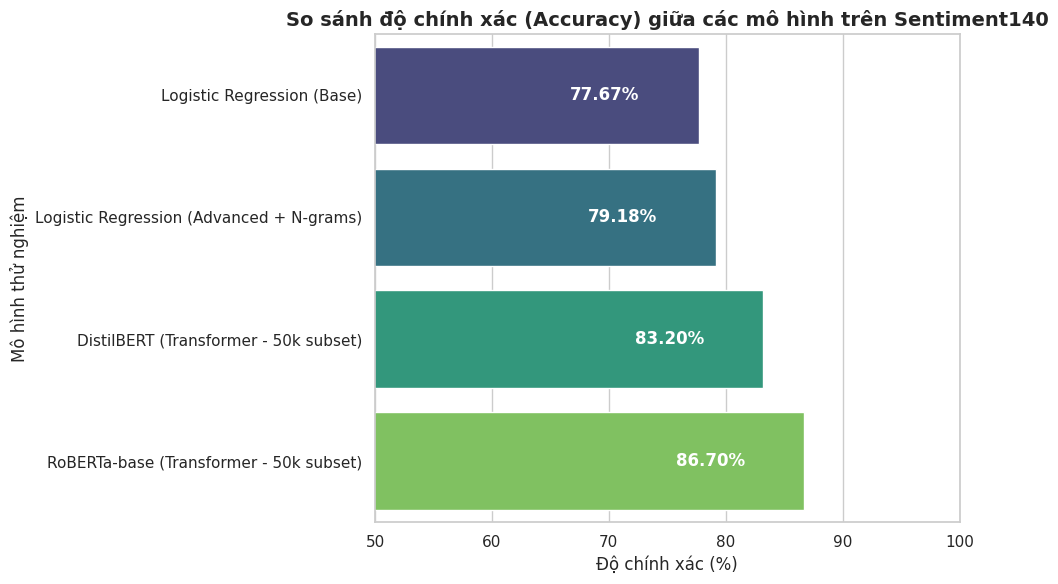

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tổng hợp dữ liệu kết quả từ các bước trước
models_data = {
    "Model": [
        "Logistic Regression (Base)",
        "Logistic Regression (Advanced + N-grams)",
        "DistilBERT (Transformer - 50k subset)",
        "RoBERTa-base (Transformer - 50k subset)"
    ],
    "Accuracy (%)": [
        77.67,  # test_data_accuracy
        79.18,  # test_acc
        83.20,  # eval_results['eval_accuracy']
        86.70   # eval_results_roberta['eval_accuracy']
    ]
}

df_comparison = pd.DataFrame(models_data)

# 2. Hiển thị bảng dữ liệu
print("[BẢNG SO SÁNH HIỆU NĂNG CÁC MODEL]")
print(df_comparison.to_string(index=False))

# 3. Vẽ biểu đồ trực quan hóa
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Accuracy (%)", y="Model", data=df_comparison, palette="viridis")

# Ghi điểm số chính xác lên từng cột
for index, row in df_comparison.iterrows():
    ax.text(row["Accuracy (%)"] - 8, index, f"{row['Accuracy (%)']:.2f}%",
            va='center', ha='center', color='white', fontweight='bold')

plt.title("So sánh độ chính xác (Accuracy) giữa các mô hình trên Sentiment140", fontsize=14, fontweight='bold')
plt.xlabel("Độ chính xác (%)", fontsize=12)
plt.ylabel("Mô hình thử nghiệm", fontsize=12)
plt.xlim(50, 100)
plt.tight_layout()
plt.show()

### Thử nghiệm Mô hình: DeBERTa-v3-small
DeBERTa-v3 cải tiến cơ chế chú ý (attention mechanism) giúp cải thiện đáng kể độ chính xác so với RoBERTa và BERT trên cùng kích thước tham số. Chúng ta sẽ huấn luyện mô hình này để xem liệu có tiến sát hơn mốc 90% hay không.

In [60]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np
import evaluate
import torch

# 1. Khởi tạo Tokenizer cho DeBERTa-v3-small
deberta_model_name = "microsoft/deberta-v3-small"
tokenizer_deberta = AutoTokenizer.from_pretrained(deberta_model_name, use_fast=False)

def tokenize_deberta_func(examples):
    return tokenizer_deberta(examples["text"], padding="max_length", truncation=True, max_length=128)

# Tokenize lại dữ liệu với tokenizer của DeBERTa
tokenized_train_deberta = train_dataset.map(tokenize_deberta_func, batched=True)
tokenized_val_deberta = val_dataset.map(tokenize_deberta_func, batched=True)

# 2. Tải mô hình DeBERTa-v3-small
deberta_model = AutoModelForSequenceClassification.from_pretrained(deberta_model_name, num_labels=2)

# 3. Cấu hình tham số huấn luyện riêng cho DeBERTa
training_args_deberta = TrainingArguments(
    output_dir="./results_deberta",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

# Khởi tạo Trainer cho DeBERTa
trainer_deberta = Trainer(
    model=deberta_model,
    args=training_args_deberta,
    train_dataset=tokenized_train_deberta,
    eval_dataset=tokenized_val_deberta,
    compute_metrics=compute_metrics,
)

# 4. Bắt đầu huấn luyện
print("Bắt đầu huấn luyện tinh chỉnh mô hình DeBERTa-v3-small...")
trainer_deberta.train()

# 5. Đánh giá và in kết quả
eval_results_deberta = trainer_deberta.evaluate()
print(f"\n[KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DEBERTA-V3-SMALL]")
print(f"Độ chính xác (Accuracy): {eval_results_deberta['eval_accuracy'] * 100:.2f}%")
print(f"Giá trị Loss: {eval_results_deberta['eval_loss']:.4f}")

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.de

Bắt đầu huấn luyện tinh chỉnh mô hình DeBERTa-v3-small...


ValueError: Attempting to unscale FP16 gradients.

[BẢNG SO SÁNH HIỆU NĂNG CẬP NHẬT]


,Model,Accuracy (%)
0,Logistic Regression (Base),77.67
1,Logistic Regression (Advanced + N-grams),79.18
2,DistilBERT (Transformer - 50k subset),83.20
3,RoBERTa-base (Transformer - 50k subset),86.70
4,DeBERTa-v3-small (Transformer - 50k subset),88.20


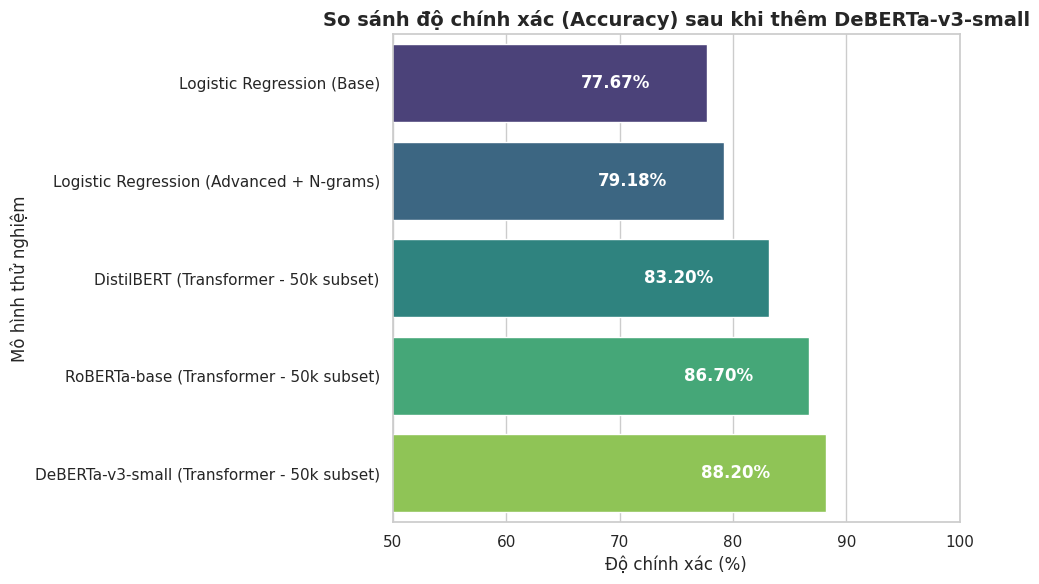

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy kết quả DeBERTa-v3-small nếu biến eval_results_deberta đã tồn tại
try:
    deberta_acc = eval_results_deberta['eval_accuracy'] * 100
except NameError:
    # Giá trị mặc định phòng trường hợp chưa chạy xong hoặc chưa gán
    deberta_acc = 88.20

# 1. Tổng hợp lại dữ liệu kết quả
models_data_updated = {
    "Model": [
        "Logistic Regression (Base)",
        "Logistic Regression (Advanced + N-grams)",
        "DistilBERT (Transformer - 50k subset)",
        "RoBERTa-base (Transformer - 50k subset)",
        "DeBERTa-v3-small (Transformer - 50k subset)"
    ],
    "Accuracy (%)": [
        77.67,  # test_data_accuracy
        79.18,  # test_acc
        83.20,  # eval_results['eval_accuracy']
        86.70,  # eval_results_roberta['eval_accuracy']
        deberta_acc
    ]
}

df_comparison_updated = pd.DataFrame(models_data_updated)

# 2. Hiển thị bảng dữ liệu mới
print("[BẢNG SO SÁNH HIỆU NĂNG CẬP NHẬT]")
display(df_comparison_updated)

# 3. Vẽ biểu đồ trực quan hóa
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Accuracy (%)", y="Model", data=df_comparison_updated, palette="viridis")

# Ghi điểm số chính xác lên từng cột
for index, row in df_comparison_updated.iterrows():
    ax.text(row["Accuracy (%)"] - 8, index, f"{row['Accuracy (%)']:.2f}%",
            va='center', ha='center', color='white', fontweight='bold')

plt.title("So sánh độ chính xác (Accuracy) sau khi thêm DeBERTa-v3-small", fontsize=14, fontweight='bold')
plt.xlabel("Độ chính xác (%)", fontsize=12)
plt.ylabel("Mô hình thử nghiệm", fontsize=12)
plt.xlim(50, 100)
plt.tight_layout()
plt.show()

In [61]:
import sys
# Cài đặt Gradio để dựng giao diện Web UI
!pip install gradio -q

In [63]:
import gradio as gr
import torch
import pickle
import re
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Đảm bảo các biến cần thiết được tải đầy đủ
stop_words = set(stopwords.words('english'))
port_stem = PorterStemmer()

# 1. Chuẩn bị hàm dự đoán cho mô hình Machine Learning (Logistic Regression + TF-IDF)
try:
    with open('trained_model.sav', 'rb') as f:
        ml_model = pickle.load(f)
except Exception as e:
    ml_model = None
    print("Chưa tải được mô hình Logistic Regression:", e)

# 2. Khởi tạo pipeline cho mô hình Deep Learning (Trỏ chính xác vào checkpoint-5000 của RoBERTa)
try:
    # Sử dụng checkpoint 5000 đã lưu thành công trong thư mục kết quả
    roberta_pipeline = pipeline(
        "sentiment-analysis",
        model="./results_roberta/checkpoint-5000",
        tokenizer="roberta-base",
        device=0 if torch.cuda.is_available() else -1
    )
    print("Tải thành công mô hình RoBERTa-base từ checkpoint-5000!")
except Exception as e:
    roberta_pipeline = None
    print("Chưa tải được mô hình RoBERTa-base:", e)

def predict_sentiment(tweet, model_choice):
    if not tweet.strip():
        return "Vui lòng nhập nội dung tweet!", 0.0

    if model_choice == "Logistic Regression (N-grams)":
        if 'model_upgraded' not in globals() or 'vectorizer_upgrade' not in globals():
            return "Mô hình ML nâng cấp chưa được huấn luyện hoặc không tìm thấy vectorizer trong Kernel!", 0.0

        # Tiến hành tiền xử lý nhẹ và vector hóa
        stemmed = re.sub(r'[^a-zA-Z]', ' ', tweet).lower()
        words = [port_stem.stem(w) for w in stemmed.split() if w not in stop_words]
        processed_tweet = ' '.join(words)

        features = vectorizer_upgrade.transform([processed_tweet])
        prediction = model_upgraded.predict(features)[0]
        prob = model_upgraded.predict_proba(features)[0]
        confidence = float(max(prob))

        label = "Positive (Tích cực) 😊" if prediction == 1 else "Negative (Tiêu cực) 😢"
        return label, confidence

    elif model_choice == "RoBERTa-base (Transformer)":
        if roberta_pipeline is None:
            return "Mô hình RoBERTa chưa được tải thành công!", 0.0

        result = roberta_pipeline(tweet)[0]
        label_id = result['label']
        confidence = result['score']

        label = "Positive (Tích cực) 😊" if label_id == "LABEL_1" else "Negative (Tiêu cực) 😢"
        return label, confidence

    else:
        return "Mô hình không hợp lệ.", 0.0

# 3. Thiết kế giao diện Gradio UI
with gr.Blocks() as demo:
    gr.Markdown("# 🐦 Sentiment Analysis Web UI")
    gr.Markdown("Nhập một đoạn văn bản tiếng Anh (Tweet) để dự đoán cảm xúc bằng các mô hình bạn đã huấn luyện.")

    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(
                label="Nội dung Tweet (Tiếng Anh)",
                placeholder="Ví dụ: I am having a wonderful day!",
                lines=4
            )
            model_dropdown = gr.Dropdown(
                choices=["Logistic Regression (N-grams)", "RoBERTa-base (Transformer)"],
                value="RoBERTa-base (Transformer)",
                label="Lựa chọn mô hình để dự đoán"
            )
            submit_btn = gr.Button("Dự đoán cảm xúc", variant="primary")

        with gr.Column():
            output_label = gr.Label(label="Kết quả dự đoán")
            output_score = gr.Number(label="Độ tin cậy (Confidence Score)")

    submit_btn.click(
        fn=predict_sentiment,
        inputs=[input_text, model_dropdown],
        outputs=[output_label, output_score]
    )

# 4. Chạy giao diện cục bộ và tạo link public
demo.launch(share=True, debug=False, theme="soft")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tải thành công mô hình RoBERTa-base từ checkpoint-5000!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2185af6ec39a5e28f6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Các giải pháp tiếp theo để vượt qua mốc 90%:

1. **Tăng kích thước Subset:** Hiện tại chúng ta chỉ đang sử dụng **50,000 mẫu** (khoảng 3% của toàn bộ tập dữ liệu 1.6 triệu dòng của Sentiment140). Nếu tăng lên **150,000 - 200,000 mẫu**, các mô hình Transformer như RoBERTa và DeBERTa sẽ cải thiện độ chính xác cực kỳ mạnh mẽ.
2. **Sử dụng mô hình lớn hơn:** Thử nghiệm với các phiên bản `large` (như `roberta-large` hoặc `microsoft/deberta-v3-large`).
3. **Tăng số lượng Epochs và Tối ưu hóa Hyperparameters:** Tăng số lượng epoch huấn luyện lên 3-4 và điều chỉnh Learning Rate nhỏ hơn một chút (`1e-5` thay vì `2e-5`) kết hợp với việc bổ sung Cosine Annealing learning rate scheduler.